Notebook for the final project. Runs the code that generates
all the figures and results in my report.

Run the cells top to bottom. The `code/` folder has the modules.

## Setup

Imports and path setup so the modules in `code/` are importable.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# add code/ to path so we can import from it
sys.path.insert(0, os.path.abspath('code'))

from kuka_dh import (
    KR6_SDH, Q_ZERO, Q_READY, Q_MIN, Q_MAX, QD_MAX,
    dh_link, kr6_frames, kr6_fk, clip_to_limits
)
from kuka_viz import setup_3d_axes, draw_stick_figure, draw_frame
from trajectories import quintic, quintic_vec
from problem5 import jacobian
from problem6 import ik_position, ik_velocity, round_trip, L_FORE, BETA_OFF

np.set_printoptions(precision=4, suppress=True)
print(f"imports OK; numpy {np.__version__}, matplotlib {plt.matplotlib.__version__}")

imports OK; numpy 2.2.6, matplotlib 3.10.3


## Problem 1 - Robot Identification

Print the specs for the KUKA KR 6 R900 sixx and verify the reach from the DH table.

In [2]:
print("=" * 66)
print(" KUKA KR 6 R900 sixx  --  robot identification")
print("=" * 66)
print("Manufacturer:       KUKA Roboter GmbH (Augsburg, Germany)")
print("Model:              KR 6 R900 sixx (KR AGILUS family)")
print("Axes:               6 (all revolute)")
print("Reach:              0.901 m to wrist centre  (0.981 m to flange)")
print("Payload:            6 kg max (3 kg rated)")
print("Arm mass:           approx. 52 kg")
print("Repeatability:      +/- 0.03 mm  (ISO 9283)")
print("Working envelope:   2.85 m^3")
print("Protection class:   IP54")
print("Controller:         KR C4 compact")
print("Actuation:          brushless AC servos + per-axis reducers;")
print("                    A5/A6 toothed-belt driven")
print("Sensing:            joint resolvers + motor brakes on every axis")
print()

print("Joint limits (rad):")
print(f"  q_min = {np.round(Q_MIN, 4).tolist()}")
print(f"  q_max = {np.round(Q_MAX, 4).tolist()}")
print("Joint limits (deg):")
print(f"  q_min = {np.round(np.degrees(Q_MIN), 1).tolist()}")
print(f"  q_max = {np.round(np.degrees(Q_MAX), 1).tolist()}")

# check reach from the DH table
frames = kr6_frames(Q_ZERO)
r_wc = np.linalg.norm(frames[5].t[:2])
r_flange = np.linalg.norm(frames[6].t[:2])
print()
print(f"Reach check: wrist center at q=0 is {r_wc:.4f} m from A1 axis")
print(f"(KUKA says 0.901 m - matches)")

 KUKA KR 6 R900 sixx  --  robot identification
Manufacturer:       KUKA Roboter GmbH (Augsburg, Germany)
Model:              KR 6 R900 sixx (KR AGILUS family)
Axes:               6 (all revolute)
Reach:              0.901 m to wrist centre  (0.981 m to flange)
Payload:            6 kg max (3 kg rated)
Arm mass:           approx. 52 kg
Repeatability:      +/- 0.03 mm  (ISO 9283)
Working envelope:   2.85 m^3
Protection class:   IP54
Controller:         KR C4 compact
Actuation:          brushless AC servos + per-axis reducers;
                    A5/A6 toothed-belt driven
Sensing:            joint resolvers + motor brakes on every axis

Joint limits (rad):
  q_min = [-2.9671, -3.3161, -2.0944, -3.2289, -2.0944, -6.1087]
  q_max = [2.9671, 0.7854, 2.7227, 3.2289, 2.0944, 6.1087]
Joint limits (deg):
  q_min = [-170.0, -190.0, -120.0, -185.0, -120.0, -350.0]
  q_max = [170.0, 45.0, 156.0, 185.0, 120.0, 350.0]

Reach check: wrist center at q=0 is 0.9000 m from A1 axis
(KUKA says 0.901 m - mat

## Problem 2 - DH Table and Frames

Print the DH table and draw all the frames at q=0.

In [3]:
print(" i   a_i [m]   alpha_i [rad]   d_i [m]   theta-offset")
print(" --  --------  --------------  --------  ------------")
for i, row in enumerate(KR6_SDH):
    a, al, d, th = row
    print(f"  {i+1}   {a:+7.4f}    {al:+8.4f}       {d:+7.4f}   {th:+8.4f}")

 i   a_i [m]   alpha_i [rad]   d_i [m]   theta-offset
 --  --------  --------------  --------  ------------
  1   +0.0250     -1.5708       +0.4000    +0.0000
  2   +0.4550     +0.0000       +0.0000    +0.0000
  3   +0.0350     -1.5708       +0.0000    -1.5708
  4   +0.0000     +1.5708       +0.4200    -3.1416
  5   +0.0000     -1.5708       +0.0000    +0.0000
  6   +0.0000     +0.0000       +0.0800    -3.1416


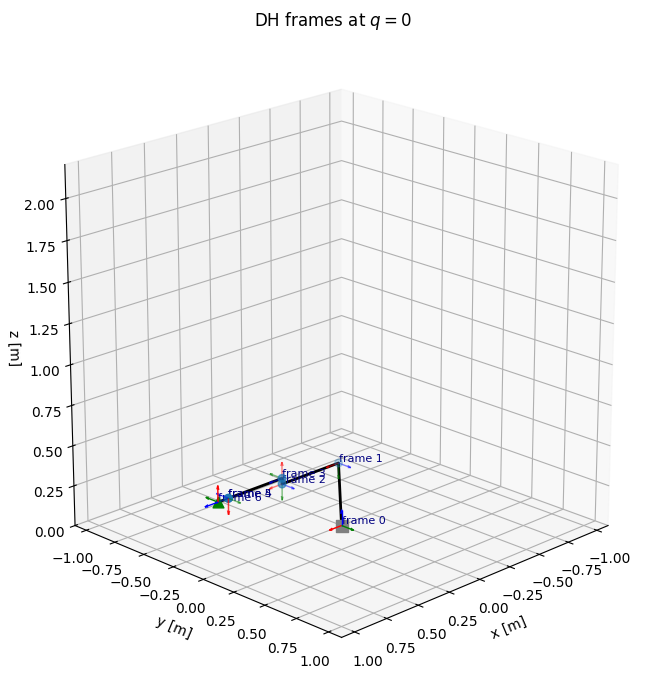

In [4]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
setup_3d_axes(ax, lim=1.1, title=r"DH frames at $q=0$")
draw_stick_figure(ax, Q_ZERO, show_frames=True, frame_len=0.10)

frames = kr6_frames(Q_ZERO)
for i, T in enumerate(frames):
    p = T.t
    ax.text(p[0] + 0.02, p[1] + 0.02, p[2] + 0.02, f"frame {i}",
            fontsize=8, color='navy')

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/problem2_frames.png', dpi=140, bbox_inches='tight')
plt.show()

## Problem 3 - Forward Kinematics

Compute each link transform and the full T_0^6 at q_ready, plus the intermediate frame origins.

In [5]:
print(f"q_ready = {Q_READY}")
print()
print("Per-link transforms at q_ready:")
for i in range(6):
    a, alpha, d, theta_off = KR6_SDH[i]
    theta = theta_off + Q_READY[i]
    T = dh_link(a, alpha, d, theta)
    print(f"\nT_{i}^{i+1} (q{i+1} = {Q_READY[i]:+.4f}):")
    print(np.array2string(T, precision=4, suppress_small=True, prefix=' '))

print()
print("-" * 50)
T06 = kr6_fk(Q_READY).A
print("T_0^6 at q_ready:")
print(np.array2string(T06, precision=4, suppress_small=True, prefix=' '))
print(f"\nflange position: {np.round(T06[:3, 3], 4)}")

q_ready = [ 0.     -1.0472  1.0472  0.      0.7854  0.    ]

Per-link transforms at q_ready:

T_0^1 (q1 = +0.0000):
[[ 1.    -0.    -0.     0.025]
  [ 0.     0.     1.     0.   ]
  [ 0.    -1.     0.     0.4  ]
  [ 0.     0.     0.     1.   ]]

T_1^2 (q2 = -1.0472):
[[ 0.5     0.866  -0.      0.2275]
  [-0.866   0.5    -0.     -0.394 ]
  [ 0.      0.      1.      0.    ]
  [ 0.      0.      0.      1.    ]]

T_2^3 (q3 = +1.0472):
[[ 0.866   0.      0.5     0.0303]
  [-0.5     0.      0.866  -0.0175]
  [ 0.     -1.      0.      0.    ]
  [ 0.      0.      0.      1.    ]]

T_3^4 (q4 = +0.0000):
[[-1.    0.   -0.   -0.  ]
  [-0.   -0.    1.   -0.  ]
  [ 0.    1.    0.    0.42]
  [ 0.    0.    0.    1.  ]]

T_4^5 (q5 = +0.7854):
[[ 0.7071 -0.     -0.7071  0.    ]
  [ 0.7071  0.      0.7071  0.    ]
  [ 0.     -1.      0.      0.    ]
  [ 0.      0.      0.      1.    ]]

T_5^6 (q6 = +0.0000):
[[-1.    0.   -0.   -0.  ]
  [-0.   -1.    0.   -0.  ]
  [ 0.    0.    1.    0.08]
  [ 0.    0.  

In [6]:
# intermediate frame origins at q_ready
frames = kr6_frames(Q_READY)
print("Frame origins at q_ready:")
for i, T in enumerate(frames):
    print(f"  frame {i}: {np.round(T.t, 4)} m")

Frame origins at q_ready:
  frame 0: [0. 0. 0.] m
  frame 1: [0.025 0.    0.4  ] m
  frame 2: [ 0.2525 -0.      0.794 ] m
  frame 3: [ 0.2525 -0.      0.829 ] m
  frame 4: [ 0.6725 -0.      0.829 ] m
  frame 5: [ 0.6725 -0.      0.829 ] m
  frame 6: [ 0.7291 -0.      0.8856] m


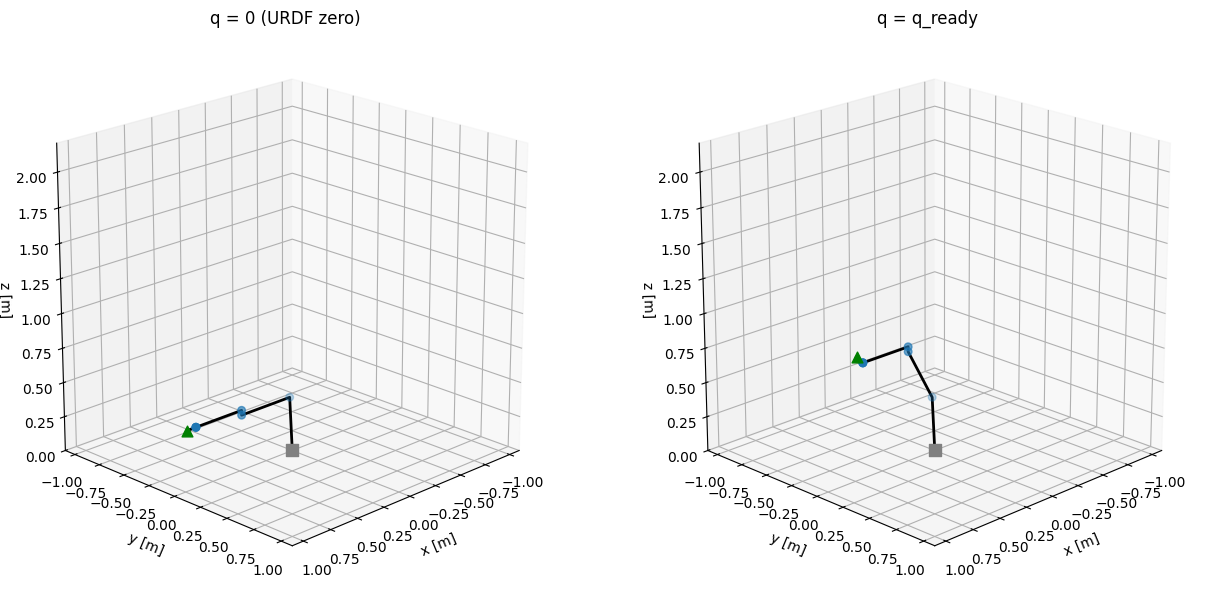

In [7]:
fig = plt.figure(figsize=(13, 6))
for idx, (q, title) in enumerate([
    (Q_ZERO,  "q = 0 (URDF zero)"),
    (Q_READY, "q = q_ready"),
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    setup_3d_axes(ax, lim=1.1, title=title)
    draw_stick_figure(ax, q, show_frames=False)
plt.tight_layout()
plt.savefig('figures/problem3_fk_configs.png', dpi=140, bbox_inches='tight')
plt.show()

## Problem 4 - Stick Figure + Quintic Trajectories

Quintic profile for joint 1, panel of each joint moving one at a time, and the animated GIF.

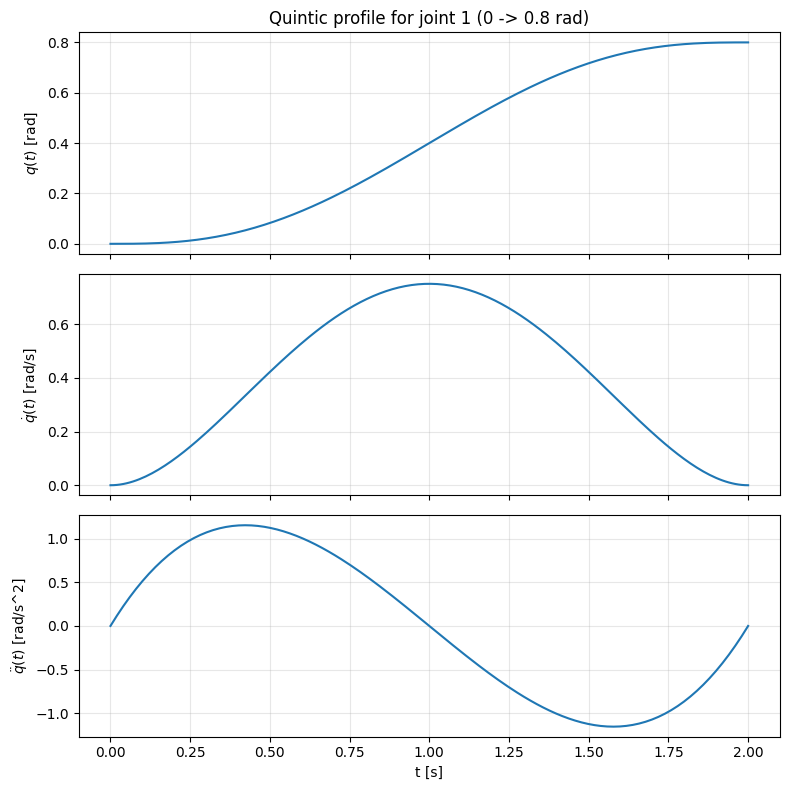


Quintic coefficients for q_0=0, q_f=0.8, T=2:
  a_3 = 1.0000
  a_4 = -0.7500
  a_5 = 0.1500


In [8]:
# quintic profile for joint 1
t, q, qd, qdd = quintic(0, 2.0, 0.0, 0.8, 0, 0, 0, 0, num_points=200)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].plot(t, q);   axes[0].set_ylabel(r'$q(t)$ [rad]')
axes[0].set_title("Quintic profile for joint 1 (0 -> 0.8 rad)")
axes[1].plot(t, qd);  axes[1].set_ylabel(r'$\dot q(t)$ [rad/s]')
axes[2].plot(t, qdd); axes[2].set_ylabel(r'$\ddot q(t)$ [rad/s^2]')
axes[2].set_xlabel('t [s]')
for a in axes:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/problem4_quintic_q1.png', dpi=140)
plt.show()

# check the coefficients
print("\nQuintic coefficients for q_0=0, q_f=0.8, T=2:")
print(f"  a_3 = {10*0.8/2**3:.4f}")
print(f"  a_4 = {-15*0.8/2**4:.4f}")
print(f"  a_5 = {6*0.8/2**5:.4f}")

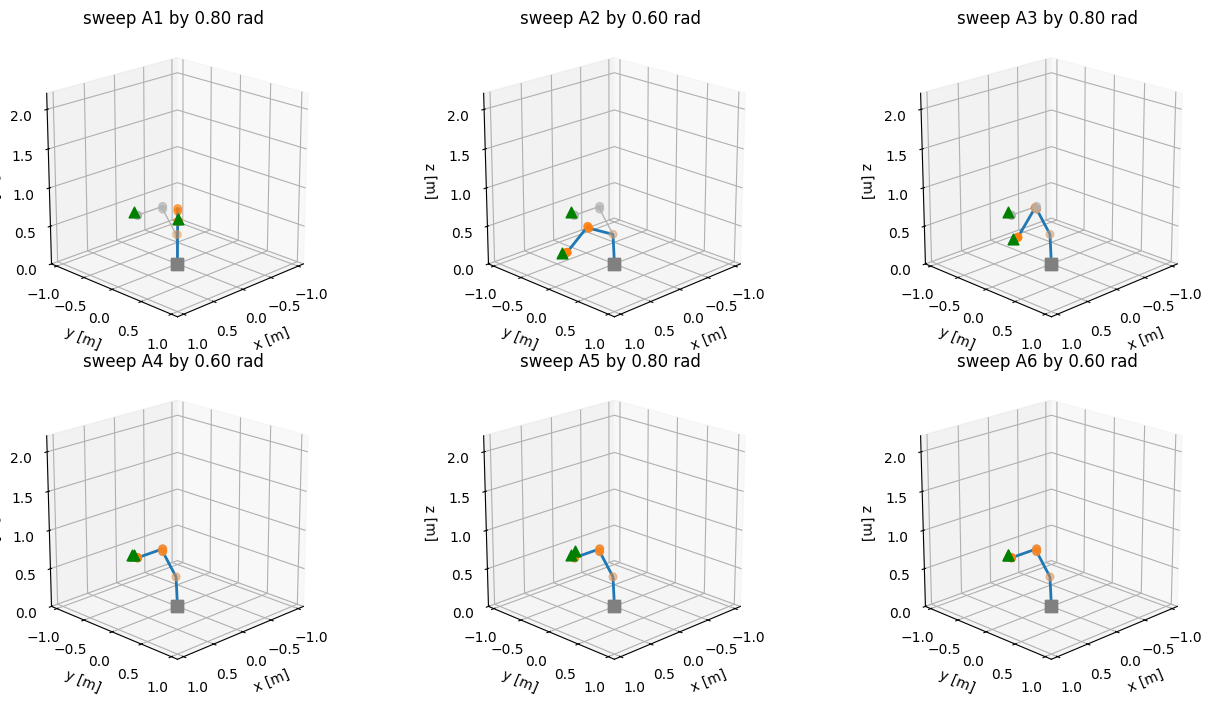

In [9]:
# sweep each joint one at a time
DQ = np.array([0.8, 0.6, 0.8, 0.6, 0.8, 0.6])

fig = plt.figure(figsize=(14, 7))
for j in range(6):
    ax = fig.add_subplot(2, 3, j + 1, projection='3d')
    setup_3d_axes(ax, lim=1.1, title=f"sweep A{j+1} by {DQ[j]:.2f} rad")
    draw_stick_figure(ax, Q_READY, show_frames=False,
                      link_color='0.7', joint_color='0.7', lw=1)
    q_shift = Q_READY.copy(); q_shift[j] += DQ[j]
    draw_stick_figure(ax, q_shift, show_frames=False,
                      link_color='tab:blue', joint_color='tab:orange', lw=2)
plt.tight_layout()
plt.savefig('figures/problem4_joints_panel.png', dpi=140, bbox_inches='tight')
plt.show()

In [10]:
# generate the GIF (takes ~30 sec, skip if already there)
if not os.path.exists('animations/problem4_motion.gif'):
    from kuka_viz import animate_joint_trajectory
    N_PER = 50
    Q_list = []
    q_cur = Q_READY.copy()
    for j in range(6):
        qf = q_cur.copy(); qf[j] += DQ[j]
        _, Qout, _, _ = quintic_vec(0, 1.0, q_cur, qf, num_points=N_PER)
        _, Qback, _, _ = quintic_vec(0, 1.0, qf, q_cur, num_points=N_PER)
        Q_list.append(Qout); Q_list.append(Qback)
    Q_full = np.concatenate(Q_list, axis=0)
    os.makedirs('animations', exist_ok=True)
    animate_joint_trajectory(Q_full,
                             title="KR6 joint-at-a-time quintic sweep",
                             filename='animations/problem4_motion.gif',
                             fps=18, lim=1.1, ee_trail=True)
else:
    print("animations/problem4_motion.gif already exists -- skipped")

animations/problem4_motion.gif already exists -- skipped


## Problem 5 - Jacobian and Singularities

Compute and validate the Jacobian, sweep q5 toward the wrist singularity,
and show velocity arrows on the end effector.

In [11]:
J = jacobian(Q_READY)
print("J(q_ready):")
print(np.array2string(J, precision=4, suppress_small=True, prefix=' '))
print()
sv = np.linalg.svd(J, compute_uv=False)
print(f"det(J)            = {np.linalg.det(J):.6f}")
print(f"manipulability    = {np.sqrt(abs(np.linalg.det(J @ J.T))):.6f}")
print(f"singular values   = {np.round(sv, 4).tolist()}")
print()

# validate against finite differences
rng = np.random.default_rng(7)
worst = 0.0
for _ in range(50):
    q = rng.uniform(-1.2, 1.2, 6)
    Ja = jacobian(q)
    J_fd = np.zeros((6, 6))
    h = 1e-6
    for j in range(6):
        qp = q.copy(); qp[j] += h
        qm = q.copy(); qm[j] -= h
        Tp = kr6_fk(qp); Tm = kr6_fk(qm)
        dp = (Tp.t - Tm.t) / (2*h)
        R_err = Tp.R @ Tm.R.T
        w = 0.5 * np.array([R_err[2,1]-R_err[1,2],
                            R_err[0,2]-R_err[2,0],
                            R_err[1,0]-R_err[0,1]]) / (2*h)
        J_fd[:, j] = np.concatenate([dp, w])
    worst = max(worst, np.max(np.abs(Ja - J_fd)))
print(f"FD check: max error over 50 configs = {worst:.3e}")

J(q_ready):
[[ 0.      0.4856  0.0916  0.     -0.0566 -0.    ]
  [ 0.7291  0.      0.     -0.0566 -0.     -0.    ]
  [-0.     -0.7041 -0.4766 -0.      0.0566  0.    ]
  [ 0.      0.      0.      1.      0.      0.7071]
  [ 0.      1.      1.      0.     -1.     -0.    ]
  [ 1.      0.      0.     -0.     -0.      0.7071]]

det(J)            = -0.074912
manipulability    = 0.074912
singular values   = [1.9237, 1.4716, 1.135, 0.4955, 0.2847, 0.1653]

FD check: max error over 50 configs = 3.297e-10


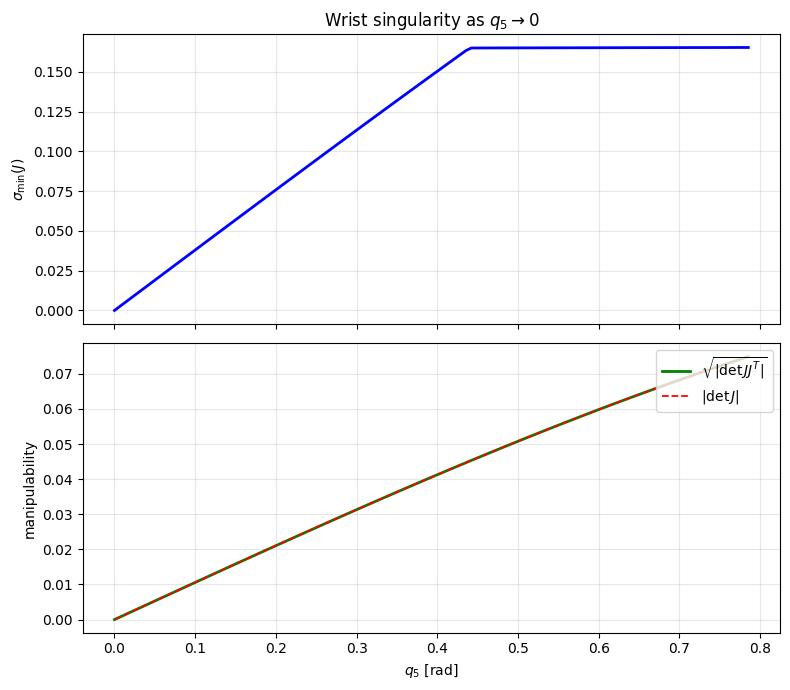

In [12]:
# sweep q5 toward 0 to show the wrist singularity
q5_vals = np.linspace(Q_READY[4], 0.0, 120)
sigmin, manip, dets = [], [], []
for v in q5_vals:
    q = Q_READY.copy(); q[4] = v
    J = jacobian(q)
    sv = np.linalg.svd(J, compute_uv=False)
    sigmin.append(sv[-1])
    manip.append(np.sqrt(abs(np.linalg.det(J @ J.T))))
    dets.append(abs(np.linalg.det(J)))

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(q5_vals, sigmin, 'b-', linewidth=2)
axes[0].set_ylabel(r'$\sigma_{\min}(J)$')
axes[0].set_title(r"Wrist singularity as $q_5 \to 0$")
axes[0].grid(alpha=0.3)
axes[1].plot(q5_vals, manip, 'g-', linewidth=2, label=r'$\sqrt{|\det J J^T|}$')
axes[1].plot(q5_vals, dets,  'r--', linewidth=1.3, label=r'$|\det J|$')
axes[1].set_ylabel('manipulability')
axes[1].set_xlabel(r'$q_5$ [rad]')
axes[1].grid(alpha=0.3); axes[1].legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/problem5_singular_sweep.png', dpi=140)
plt.show()

qdot  = [ 0.6  0.4 -0.3  0.5  0.3  0. ] rad/s
v     = [ 0.1498  0.4092 -0.1217] m/s   (|v| = 0.4524)
omega = [ 0.5 -0.2  0.6] rad/s (|w| = 0.8062)


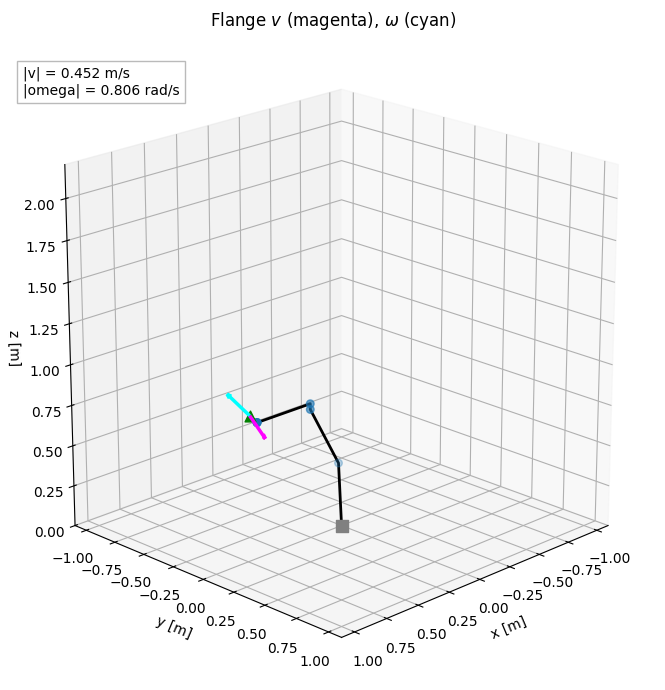

In [13]:
# compute and show velocity vectors at the end effector
qdot = np.array([0.6, 0.4, -0.3, 0.5, 0.3, 0.0])
J = jacobian(Q_READY)
twist = J @ qdot
v = twist[:3]; w = twist[3:]

print(f"qdot  = {qdot} rad/s")
print(f"v     = {np.round(v, 4)} m/s   (|v| = {np.linalg.norm(v):.4f})")
print(f"omega = {np.round(w, 4)} rad/s (|w| = {np.linalg.norm(w):.4f})")

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
setup_3d_axes(ax, lim=1.1, title=r'Flange $v$ (magenta), $\omega$ (cyan)')
draw_stick_figure(ax, Q_READY, show_frames=False)
p = kr6_fk(Q_READY).t
ax.quiver(p[0], p[1], p[2], v[0], v[1], v[2],
          color='magenta', linewidth=2.5, arrow_length_ratio=0.15,
          length=0.5, normalize=False)
ax.quiver(p[0], p[1], p[2], 0.25*w[0], 0.25*w[1], 0.25*w[2],
          color='cyan', linewidth=2.5, arrow_length_ratio=0.15)
ax.text2D(0.02, 0.95,
          f'|v| = {np.linalg.norm(v):.3f} m/s\n|omega| = {np.linalg.norm(w):.3f} rad/s',
          transform=ax.transAxes, fontsize=10, verticalalignment='top',
          bbox=dict(facecolor='white', alpha=0.9, edgecolor='0.7'))
plt.tight_layout()
plt.savefig('figures/problem5_velocity_arrows.png', dpi=140, bbox_inches='tight')
plt.show()

In [14]:
# check that known singular configs give det(J) ~ 0
q_shoulder = [0, -1.7601, 0.4168, 0, np.pi/4, 0]
q_elbow = [0, 0, 0.0831, 0, np.pi/4, 0]
q_wrist = [0, -np.pi/3, np.pi/3, 0, 0, 0]

for name, q in [("Shoulder", q_shoulder), ("Elbow", q_elbow), ("Wrist", q_wrist)]:
    J = jacobian(q)
    print(f"{name}: det J = {np.linalg.det(J):.2e}")

Shoulder: det J = -3.80e-07
Elbow: det J = 5.04e-06
Wrist: det J = 7.35e-18


## Problem 6 - Closed-Form IK (Pieper)

Round-trip validation, single target reconstruction, and the 4 IK branches.

In [15]:
# link dimensions used in the IK
print(f"a_1 (shoulder offset) = {KR6_SDH[0, 0]:.4f} m")
print(f"d_1 (shoulder height) = {KR6_SDH[0, 2]:.4f} m")
print(f"a_2 (upper arm)       = {KR6_SDH[1, 0]:.4f} m")
print(f"a_3 (elbow offset)    = {KR6_SDH[2, 0]:.4f} m")
print(f"d_4 (forearm)         = {KR6_SDH[3, 2]:.4f} m")
print(f"d_6 (wrist->flange)   = {KR6_SDH[5, 2]:.4f} m")
print()
print(f"L_fore = sqrt(a3^2 + d4^2) = {L_FORE:.6f} m")
print(f"beta   = atan2(a3, d4)     = {BETA_OFF:.6f} rad = {np.degrees(BETA_OFF):.4f} deg")

a_1 (shoulder offset) = 0.0250 m
d_1 (shoulder height) = 0.4000 m
a_2 (upper arm)       = 0.4550 m
a_3 (elbow offset)    = 0.0350 m
d_4 (forearm)         = 0.4200 m
d_6 (wrist->flange)   = 0.0800 m

L_fore = sqrt(a3^2 + d4^2) = 0.421456 m
beta   = atan2(a3, d4)     = 0.083141 rad = 4.7636 deg


q_true = [ 0.3    -0.8     0.5     0.2     0.7854  0.1   ]
q_sol  = [ 0.3    -0.8     0.5     0.2     0.7854  0.1   ]
pos error = 0.0000 mm
rot error = 9.32e-16


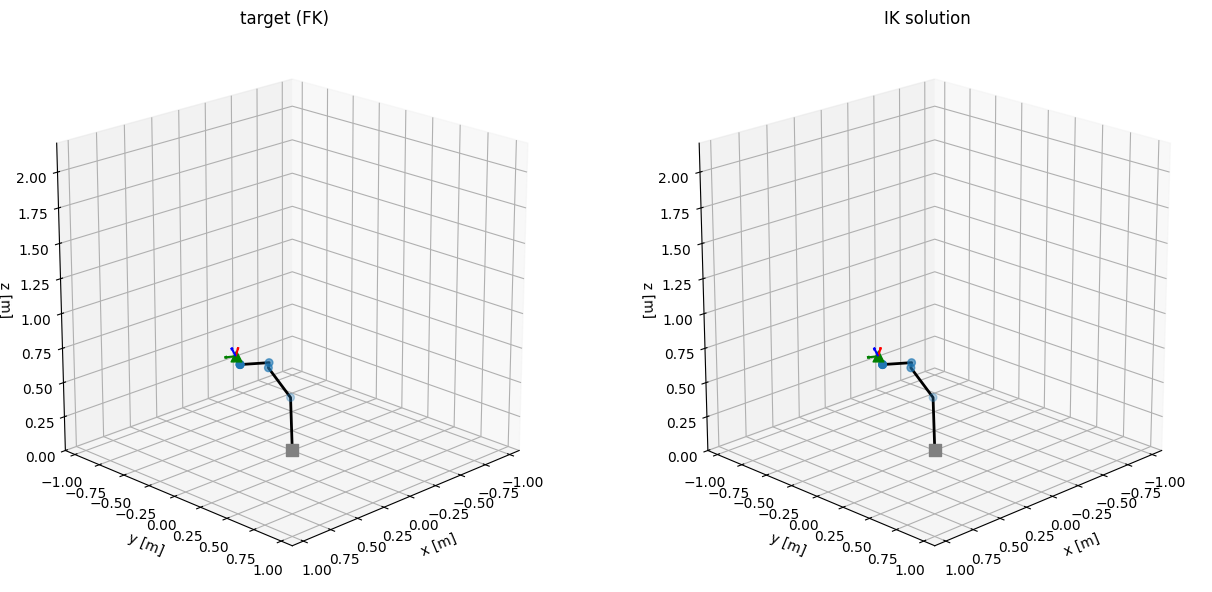

In [16]:
# test: FK -> IK -> FK
q_true = np.array([0.3, -0.8, 0.5, 0.2, 0.7854, 0.1])
T_target = kr6_fk(q_true)
q_sol = ik_position(T_target, elbow_up=True, shoulder_front=True)
T_sol = kr6_fk(q_sol)

print(f"q_true = {np.round(q_true, 4)}")
print(f"q_sol  = {np.round(q_sol, 4)}")
print(f"pos error = {np.linalg.norm(T_sol.t - T_target.t)*1000:.4f} mm")
print(f"rot error = {np.linalg.norm(T_sol.R - T_target.R):.2e}")

fig = plt.figure(figsize=(13, 6))
for idx, (q, label) in enumerate([
    (q_true, "target (FK)"),
    (q_sol,  "IK solution"),
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    setup_3d_axes(ax, lim=1.1, title=label)
    draw_stick_figure(ax, q, show_frames=False)
    draw_frame(ax, kr6_fk(q), length=0.08)
plt.tight_layout()
plt.savefig('figures/problem6_ik_check.png', dpi=140, bbox_inches='tight')
plt.show()

In [17]:
# stress test: 500 random round trips
rng = np.random.default_rng(42)
pos_err, rot_err = [], []
for _ in range(500):
    q = rng.uniform([-2.9, -2.5, -1.5, -2.5, 0.3, -2.5],
                    [+2.9, +0.5, +2.0, +2.5, +1.5, +2.5])
    T = kr6_fk(q)
    try:
        q_s = ik_position(T, elbow_up=q[2] >= 0, shoulder_front=True)
        Ts = kr6_fk(q_s)
        pos_err.append(np.linalg.norm(Ts.t - T.t))
        rot_err.append(np.linalg.norm(Ts.R - T.R))
    except Exception:
        pass
pos_err = np.array(pos_err); rot_err = np.array(rot_err)
print(f"Round trip over {len(pos_err)} configs:")
print(f"  max pos error = {pos_err.max():.3e} m  ({pos_err.max()*1000:.4f} mm)")
print(f"  max rot error = {rot_err.max():.3e}")

Round trip over 500 configs:
  max pos error = 5.979e-16 m  (0.0000 mm)
  max rot error = 2.470e-15


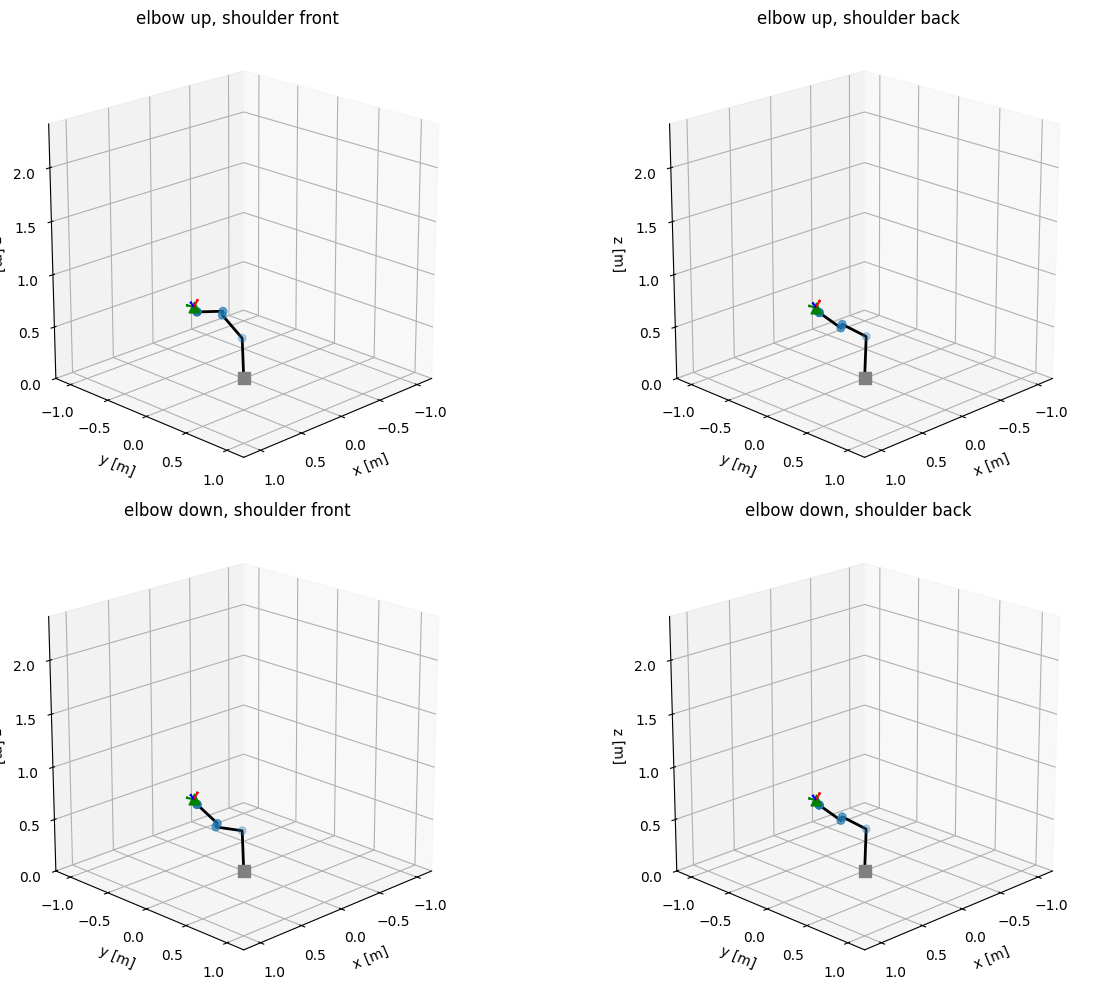

In [18]:
# show the 4 IK branches
q_true = np.array([0.2, -0.8, 0.5, 0.0, 0.6, 0.0])
T_target = kr6_fk(q_true)

fig = plt.figure(figsize=(14, 10))
idx = 1
for elbow in (True, False):
    for shoulder in (True, False):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        label = (f"elbow {'up' if elbow else 'down'}, "
                 f"shoulder {'front' if shoulder else 'back'}")
        setup_3d_axes(ax, lim=1.2, title=label)
        try:
            q = ik_position(T_target, elbow_up=elbow, shoulder_front=shoulder)
            draw_stick_figure(ax, q, show_frames=False)
            draw_frame(ax, kr6_fk(q), length=0.08)
        except Exception as e:
            ax.text2D(0.2, 0.5, str(e), transform=ax.transAxes)
        idx += 1
plt.tight_layout()
plt.savefig('figures/problem6_ik_branch_panel.png', dpi=140, bbox_inches='tight')
plt.show()

## Problem 7 - Task Space Trajectory + Inverse IK

Quintic in task space, then closed-form IK + J inverse at every timestep.

In [19]:
from spatialmath import SE3
from kuka_viz import animate_joint_trajectory

N_POINTS = 80
DURATION = 2.0

T_ready = kr6_fk(Q_READY)
R_fixed = T_ready.R
p_start = T_ready.t + np.array([-0.15, +0.05, +0.05])
p_end   = T_ready.t + np.array([-0.05, -0.08, -0.05])

# quintic for each axis
t,   xs, vxs, _ = quintic(0, DURATION, p_start[0], p_end[0], 0, 0, 0, 0, N_POINTS)
_,   ys, vys, _ = quintic(0, DURATION, p_start[1], p_end[1], 0, 0, 0, 0, N_POINTS)
_,   zs, vzs, _ = quintic(0, DURATION, p_start[2], p_end[2], 0, 0, 0, 0, N_POINTS)

poses = [SE3.Rt(R_fixed, np.array([xs[k], ys[k], zs[k]])) for k in range(N_POINTS)]
V = np.zeros((N_POINTS, 6))
V[:, 0] = vxs; V[:, 1] = vys; V[:, 2] = vzs

print(f"{len(poses)} samples from {np.round(p_start, 3)} to {np.round(p_end, 3)}")
print(f"peak task vel = {np.linalg.norm(V[:, :3], axis=1).max():.3f} m/s")

80 samples from [0.579 0.05  0.936] to [ 0.679 -0.08   0.836]
peak task vel = 0.180 m/s


peak joint vel = 0.481 rad/s


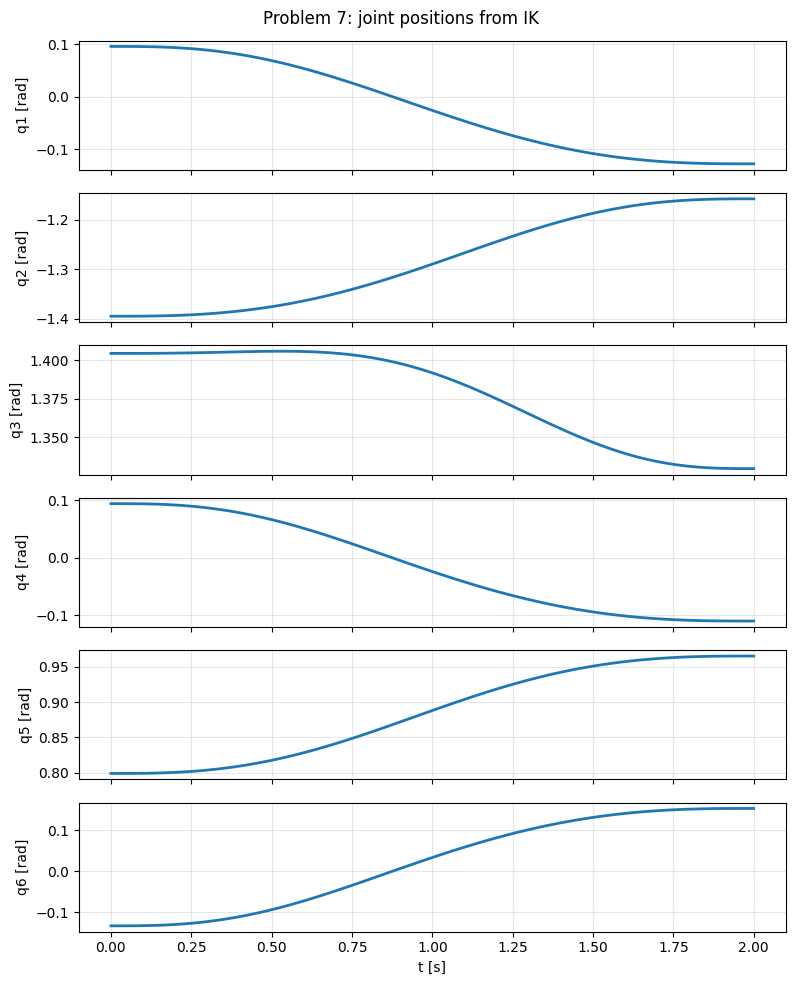

In [20]:
# IK at every timestep
Q  = np.zeros((N_POINTS, 6))
Qd = np.zeros((N_POINTS, 6))
for k, T in enumerate(poses):
    Q[k]  = ik_position(T, elbow_up=True, shoulder_front=True)
    J     = jacobian(Q[k])
    Qd[k] = np.linalg.solve(J, V[k])

np.save('figures/problem7_Q.npy',  Q)
np.save('figures/problem7_Qd.npy', Qd)
print(f"peak joint vel = {np.linalg.norm(Qd, axis=1).max():.3f} rad/s")

# plot joint positions
fig, axes = plt.subplots(6, 1, figsize=(8, 10), sharex=True)
fig.suptitle("Problem 7: joint positions from IK")
for j in range(6):
    axes[j].plot(t, Q[:, j], '-', linewidth=2)
    axes[j].set_ylabel(f"q{j+1} [rad]")
    axes[j].grid(alpha=0.3)
axes[-1].set_xlabel("t [s]")
plt.tight_layout()
plt.savefig('figures/problem7_joint_trajectories.png', dpi=140)
plt.show()

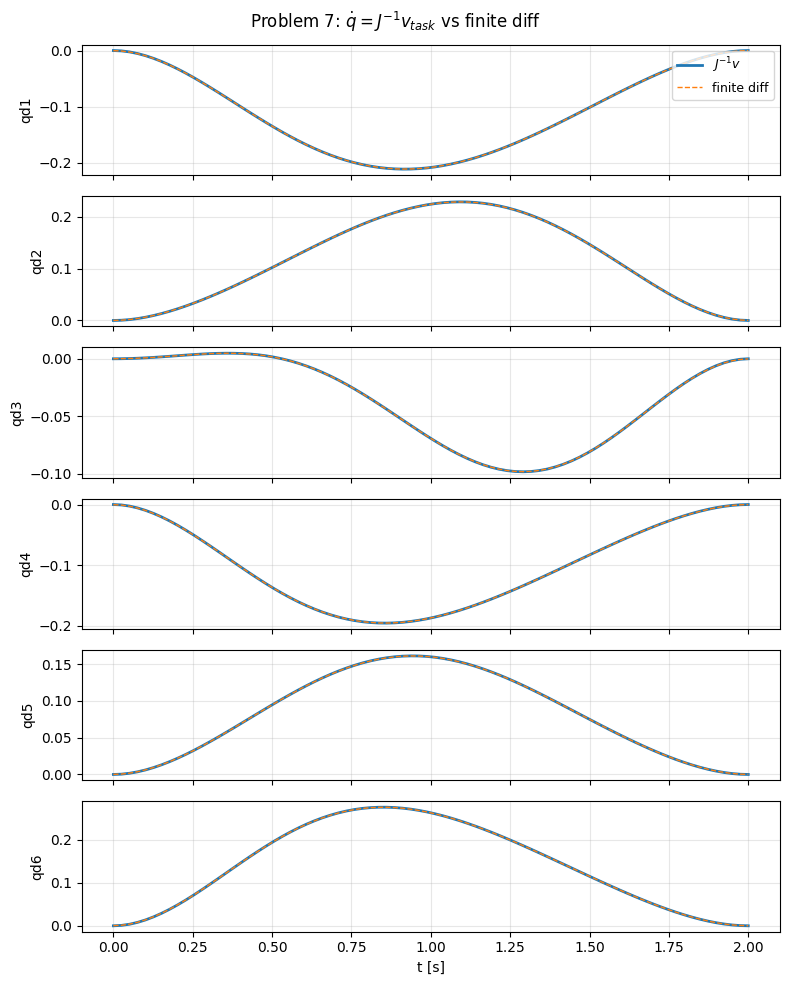

vel IK vs finite diff: max = 3.099e-04, rms = 8.392e-05 rad/s


In [21]:
# compare velocity IK against finite differences
dt = t[1] - t[0]
Qd_fd = np.gradient(Q, dt, axis=0)

fig, axes = plt.subplots(6, 1, figsize=(8, 10), sharex=True)
fig.suptitle(r"Problem 7: $\dot q = J^{-1} v_{task}$ vs finite diff")
for j in range(6):
    axes[j].plot(t, Qd[:, j],    '-',  linewidth=2, label=r"$J^{-1} v$")
    axes[j].plot(t, Qd_fd[:, j], '--', linewidth=1, label="finite diff")
    axes[j].set_ylabel(f"qd{j+1}")
    axes[j].grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel("t [s]")
plt.tight_layout()
plt.savefig('figures/problem7_joint_velocities.png', dpi=140)
plt.show()

max_err = np.max(np.abs(Qd - Qd_fd))
rms_err = np.sqrt(np.mean((Qd - Qd_fd)**2))
print(f"vel IK vs finite diff: max = {max_err:.3e}, rms = {rms_err:.3e} rad/s")

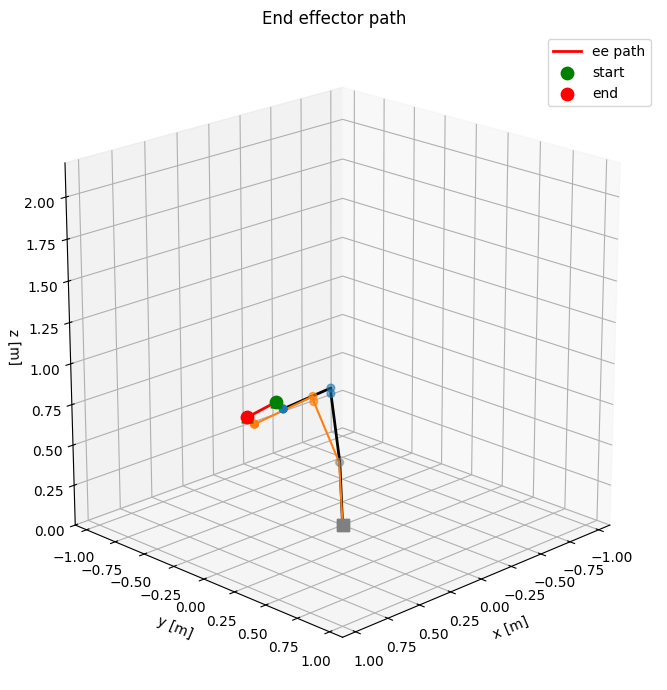

In [22]:
# plot the end effector path
ee = np.array([kr6_fk(Q[k]).t for k in range(Q.shape[0])])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
setup_3d_axes(ax, lim=1.1, title='End effector path')
draw_stick_figure(ax, Q[0],  show_frames=False)
draw_stick_figure(ax, Q[-1], show_frames=False,
                  link_color='tab:orange', joint_color='tab:orange', lw=1.5)
ax.plot(ee[:, 0], ee[:, 1], ee[:, 2], 'r-', linewidth=2, label='ee path')
ax.scatter(*p_start, color='green', s=80, label='start')
ax.scatter(*p_end,   color='red',   s=80, label='end')
ax.legend()
plt.tight_layout()
plt.savefig('figures/problem7_ee_path.png', dpi=140)
plt.show()

In [23]:
if not os.path.exists('animations/problem7_animation.gif'):
    animate_joint_trajectory(
        Q, title='Task space quintic trajectory',
        filename='animations/problem7_animation.gif',
        fps=20, lim=1.1, ee_trail=True)
else:
    print("animations/problem7_animation.gif already exists -- skipped")

animations/problem7_animation.gif already exists -- skipped


## Problem 8 - URDF

Load the URDF I built from the DH table, check that the link frames match,
and do a side-by-side comparison.

In [24]:
from urchin import URDF
from problem8 import write_urdf, draw_urdf_arm, rpy_from_R

URDF_PATH = 'urdf/kr6_sdh.urdf'
if not os.path.exists(URDF_PATH):
    write_urdf()
urdf = URDF.load(URDF_PATH)
print(f"loaded URDF with {len(urdf.joints)} joints, {len(urdf.links)} links")

# show the joint origins
print("\nJoint origins:")
for i, joint in enumerate(urdf.joints):
    if joint.joint_type != 'revolute':
        continue
    xyz = joint.origin[:3, 3]
    r, p, y = rpy_from_R(joint.origin[:3, :3])
    print(f"  joint_{i+1}: xyz=({xyz[0]:+.4f}, {xyz[1]:+.4f}, {xyz[2]:+.4f})  "
          f"rpy=({r:+.4f}, {p:+.4f}, {y:+.4f})")

loaded URDF with 13 joints, 14 links

Joint origins:
  joint_1: xyz=(+0.0000, +0.0000, +0.4000)  rpy=(+0.0000, -0.0000, +0.0000)
  joint_3: xyz=(+0.0000, +0.0000, +0.0000)  rpy=(+0.0000, -0.0000, +0.0000)
  joint_5: xyz=(+0.0000, +0.0000, +0.0000)  rpy=(+0.0000, -0.0000, -1.5708)
  joint_7: xyz=(+0.0000, +0.0000, +0.4200)  rpy=(+0.0000, -0.0000, +3.1416)
  joint_9: xyz=(+0.0000, +0.0000, +0.0000)  rpy=(+0.0000, -0.0000, +0.0000)
  joint_11: xyz=(+0.0000, +0.0000, +0.0800)  rpy=(+0.0000, -0.0000, +3.1416)


In [25]:
# compare DH frame origins with URDF frame origins
def urdf_link_origins(urdf, q):
    cfg = {f'joint_{i+1}': q[i] for i in range(6)}
    fk = urdf.link_fk(cfg=cfg)
    return {link.name: T[:3, 3] for link, T in fk.items()}

def dh_frame_origins(q):
    return [T.t for T in kr6_frames(q)]

test_configs = {
    'q_zero':   Q_ZERO,
    'q_ready':  Q_READY,
    'twisted':  np.array([ 0.5, -0.6,  0.7,  0.8,  0.5, -0.3]),
    'folded':   np.array([-1.0, -1.2,  1.5,  0.2,  0.8,  0.1]),
}

print(f"{'config':>10}  {'frame':>5}  {'DH origin':>25}  {'URDF origin':>25}  {'diff [mm]':>10}")
for name, q in test_configs.items():
    dh_origins = dh_frame_origins(q)
    urdf_origins = urdf_link_origins(urdf, q)
    urdf_names = ['base_link'] + [f'link_{i+1}' for i in range(6)]
    for i in range(7):
        d = dh_origins[i]
        u = urdf_origins[urdf_names[i]]
        err_mm = np.linalg.norm(d - u) * 1000
        d_str = f"({d[0]:+.3f}, {d[1]:+.3f}, {d[2]:+.3f})"
        u_str = f"({u[0]:+.3f}, {u[1]:+.3f}, {u[2]:+.3f})"
        print(f"{name:>10}  {i:>5}  {d_str:>25}  {u_str:>25}  {err_mm:>10.4f}")
    print()

    config  frame                  DH origin                URDF origin   diff [mm]
    q_zero      0   (+0.000, +0.000, +0.000)   (+0.000, +0.000, +0.000)      0.0000
    q_zero      1   (+0.025, +0.000, +0.400)   (+0.025, +0.000, +0.400)      0.0000
    q_zero      2   (+0.480, +0.000, +0.400)   (+0.480, +0.000, +0.400)      0.0000
    q_zero      3   (+0.480, -0.000, +0.435)   (+0.480, +0.000, +0.435)      0.0002
    q_zero      4   (+0.900, +0.000, +0.435)   (+0.900, -0.000, +0.435)      0.0021
    q_zero      5   (+0.900, +0.000, +0.435)   (+0.900, -0.000, +0.435)      0.0021
    q_zero      6   (+0.980, +0.000, +0.435)   (+0.980, -0.000, +0.435)      0.0025

   q_ready      0   (+0.000, +0.000, +0.000)   (+0.000, +0.000, +0.000)      0.0000
   q_ready      1   (+0.025, +0.000, +0.400)   (+0.025, +0.000, +0.400)      0.0000
   q_ready      2   (+0.253, -0.000, +0.794)   (+0.253, +0.000, +0.794)      0.0014
   q_ready      3   (+0.253, -0.000, +0.829)   (+0.252, +0.000, +0.829)    

In [26]:
# flange residual at q_ready
T_dh   = kr6_fk(Q_READY).A
T_urdf = list(urdf.link_fk(cfg={f'joint_{i+1}': Q_READY[i] for i in range(6)}).values())[-1]
print(f"URDF vs DH at q_ready:")
print(f"  pos error = {np.linalg.norm(T_urdf[:3, 3] - T_dh[:3, 3])*1000:.4f} mm")
print(f"  rot error = {np.linalg.norm(T_urdf[:3, :3] - T_dh[:3, :3]):.2e}")

URDF vs DH at q_ready:
  pos error = 0.0019 mm
  rot error = 3.05e-05


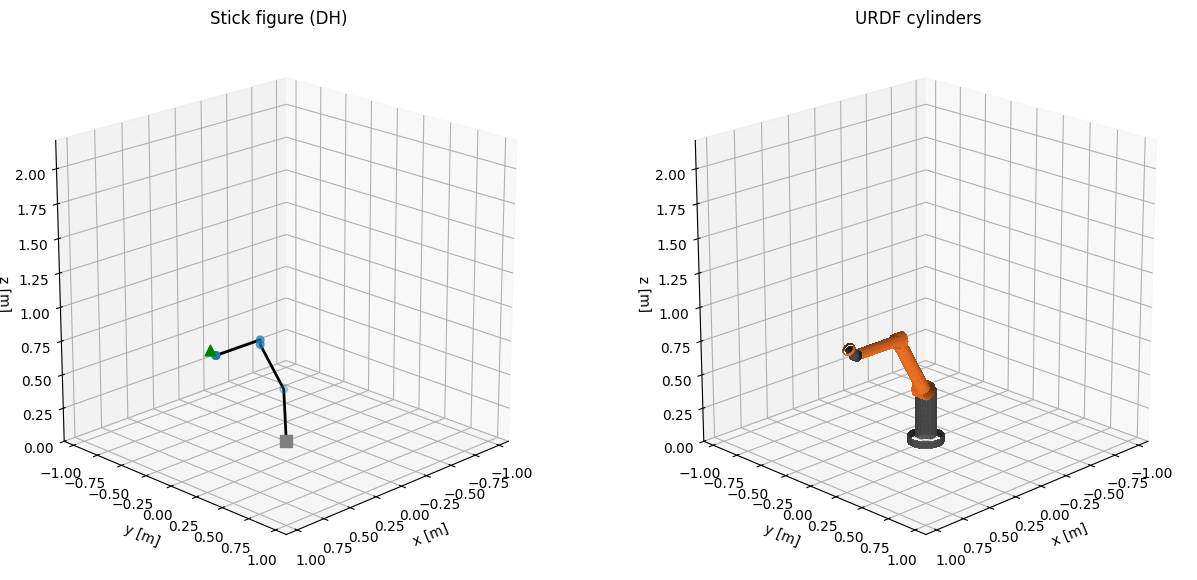

In [27]:
# side by side comparison
fig = plt.figure(figsize=(13, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
setup_3d_axes(ax1, lim=1.1, title="Stick figure (DH)")
draw_stick_figure(ax1, Q_READY, show_frames=False)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
setup_3d_axes(ax2, lim=1.1, title="URDF cylinders")
draw_urdf_arm(ax2, urdf, Q_READY)

plt.tight_layout(pad=1.5)
plt.savefig('figures/problem8_side_by_side.png', dpi=140, bbox_inches='tight')
plt.show()

## Done

All figures and results have been generated. PNGs are in `figures/`,
GIFs in `animations/`, URDF in `urdf/`.